# **Crafting a Model to Compete with ERCOTs Energy Demand Predictions (Houston coastal region)**

# 1. Compiling the Dataset and Engineering Features

In [ ]:
import json
import requests
import pandas as pd

#Personal API key received from registering with their website
API_KEY = "API_KEY"
BASE_URL = "https://api.eia.gov/v2/electricity/rto/region-sub-ba-data/data/"


def fetch_ercot_data():
    """
    Fetches hourly demand by subregion for ERCOT (all of 2024)
    via the EIA v2 API. Paginates in batches of 5000 (API max).
    """
    all_rows = []
    offset = 0

    while True:
        x_params = {
            "frequency": "hourly",
            "data": ["value"],
            "facets": {"parent": ["ERCO"]},
            "start": "2023-06-01T00",
            "end": "2024-05-31T23",
            "sort": [{"column": "period", "direction": "asc"}],
            "offset": offset,
            "length": 5000
        }

        try:
            response = requests.get(
                BASE_URL,
                params={"api_key": API_KEY},
                headers={"X-Params": json.dumps(x_params)}
            )
            response.raise_for_status()
        except requests.exceptions.RequestException as e:
            print(f"Error fetching data at offset {offset}: {e}")
            return None

        rows = response.json()["response"]["data"]
        if not rows:
            break

        all_rows.extend(rows)
        print(f"  Fetched {len(rows):,} rows (offset {offset:,})")

        if len(rows) < 5000:
            break
        offset += 5000

    df = pd.DataFrame(all_rows)
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    return df



ercot_df = fetch_ercot_data()
if ercot_df is not None:
    pivot_df = ercot_df.pivot_table(
        index="period",
        columns="subba",
        values="value"
    ).sort_index()
    print(pivot_df.head(10))

    pivot_df.to_csv("ercot_demand.csv")
    print(f"\nSaved to ercot_demand.csv ({len(pivot_df)} rows)")

Following data collection via API, we read in the ground truth - hourly energy demand. Our analysis will focus on the load zone 'COAS', which includes Houston, TX. See the image below for reference (Coast). This data spans from June 1, 2023 to May 31, 2024.

<img src="https://www.ercot.com/files/assets/2023/04/26/Weather.jpg?" width="50%">


In [3]:
import numpy as np

df_demand = pd.read_csv("../ercot_demand.csv")
df_demand["period"] = pd.to_datetime(df_demand["period"])
df_demand.head()

,period,COAS,EAST,FWES,NCEN,NRTH,SCEN,SOUT,WEST
0,2023-06-01 00:00:00,17008.0,2373.0,5998.0,20016.0,1692.0,11267.0,5320.0,1712.0
1,2023-06-01 01:00:00,16423.0,2247.0,5964.0,19076.0,1681.0,10901.0,5135.0,1502.0
2,2023-06-01 02:00:00,15935.0,2122.0,5921.0,18104.0,1615.0,10416.0,4956.0,1408.0
3,2023-06-01 03:00:00,15387.0,2025.0,5980.0,17320.0,1550.0,10007.0,4804.0,1352.0
4,2023-06-01 04:00:00,14520.0,1885.0,5876.0,16056.0,1442.0,9321.0,4457.0,1337.0


Here, we plot an arbitrary week of the year as a quick sanity check that our data has been loaded in and is accurate.

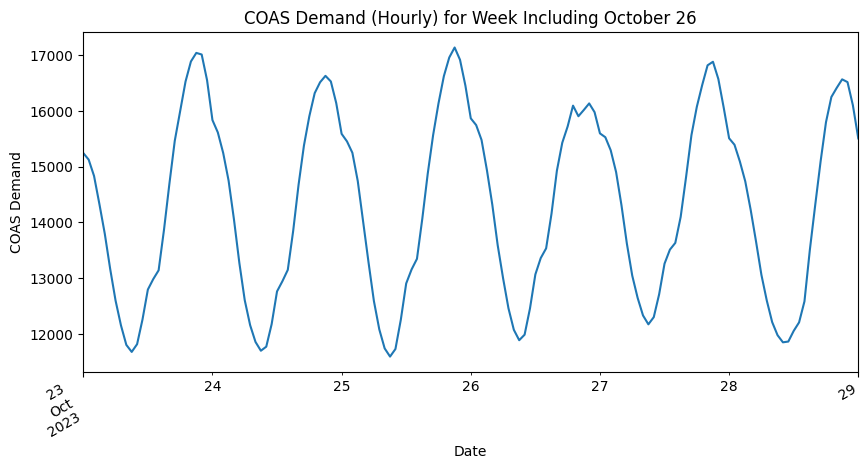

In [4]:
df_demand_oct = df_demand[df_demand["period"].dt.month == 10]
# Find the monday-sunday week in October that includes October 26
oct_26 = df_demand_oct[df_demand_oct["period"].dt.day == 26].iloc[0]["period"]
start_of_week = oct_26 - pd.Timedelta(days=oct_26.dayofweek)  # Monday of the week
end_of_week = start_of_week + pd.Timedelta(days=6)  # Sunday of the week
df_demand_week = df_demand_oct[
    (df_demand_oct["period"] >= start_of_week) &
    (df_demand_oct["period"] <= end_of_week)
]

import matplotlib.dates as mdates

ax = df_demand_week.set_index("period")["COAS"].plot(figsize=(10, 5))
ax.set_xlabel("Date")
ax.set_ylabel("COAS Demand")
ax.set_title("COAS Demand (Hourly) for Week Including October 26")
ax.figure.autofmt_xdate()

Next, we import weather data, which is a primary driver of energy demand. To prevent data leakage and ensure a fair comparison, we use day-ahead weather forecasts (MOS) rather than actual historical weather data. This mirrors the exact information available to ERCOT at the time their day-ahead predictions were made.

In [5]:
df_fair_weather = pd.read_csv("HoustonWeat.csv")
df_fair_weather.columns = df_fair_weather.columns.str.strip()

df_fair_weather.head()

# Convert to datetime
df_fair_weather['runtime'] = pd.to_datetime(df_fair_weather['runtime'])
df_fair_weather['ftime'] = pd.to_datetime(df_fair_weather['ftime'])

df_fair_weather['horizon'] = df_fair_weather['ftime'] - df_fair_weather['runtime']
df_da = df_fair_weather[
    (df_fair_weather['runtime'].dt.hour == 12) &
    (df_fair_weather['horizon'] >= pd.Timedelta(hours=12)) &
    (df_fair_weather['horizon'] <= pd.Timedelta(hours=40))
].copy()

df_da = df_da[['ftime', 'tmp', 'dpt', 'snw']].rename(columns={
    'ftime': 'valid',
    'tmp': 'tmpf',
    'dpt': 'dwpf',
    'snw': 'snowdepth'
})
df_da = df_da.drop_duplicates(subset=['valid'])

# Interpolate 3-hour data into hourly data
df_weather = df_da.set_index('valid').resample('h').interpolate(method='linear').reset_index()

df_weather.head()

,valid,tmpf,dwpf,snowdepth
0,2023-06-02 00:00:00,80.000000,67.000000,NaN
1,2023-06-02 01:00:00,78.000000,67.333333,NaN
2,2023-06-02 02:00:00,76.000000,67.666667,NaN
3,2023-06-02 03:00:00,74.000000,68.000000,NaN
4,2023-06-02 04:00:00,73.333333,68.000000,NaN


The type of day (school day, school holiday but workday, weekend, etc) may influence energy consumption patterns as well. Some day types likely influence behavioral patterns and travel tendencies. Hence we import [Houston's school district calendar](https://www.fox26houston.com/news/houston-isd-calendar-for-2023-2024-academic-school-year-updated-released) and federal holidays.

In [6]:
df_calendar = pd.read_csv('../hisd_2023_2024_day_categories_with_business(1).csv')

df_holidays = pd.read_csv("FedHolidays.csv")
df_holidays['date'] = pd.to_datetime(df_holidays['date'])
df_holidays['is_holiday'] = 1

We also account for Houston Texans home games, which bring up to 72,000 fans into the stadium, potentially altering residential and commercial energy usage patterns. We extract this schedule by parsing the structured JSON-LD data directly from the team's official website.

In [7]:
from bs4 import BeautifulSoup

resp = requests.get("https://www.houstontexans.com/schedule/2023/")
soup = BeautifulSoup(resp.text, "html.parser")
games = []
for script in soup.find_all("script", type="application/ld+json"):
    data = json.loads(script.string)
    if data.get("@type") == "SportsEvent":
        is_home = data["homeTeam"]["name"] == "Houston Texans"
        opponent = data["awayTeam"]["name"] if is_home else data["homeTeam"]["name"]
        games.append({
            "datetime": data["startDate"],
            "end_datetime": data["endDate"],
            "location": "home" if is_home else "away",
            "opponent": opponent,
        })

df_texans = pd.DataFrame(games)
df_texans["datetime"] = pd.to_datetime(df_texans["datetime"])
df_texans["end_datetime"] = pd.to_datetime(df_texans["end_datetime"])
df_texans = df_texans.sort_values("datetime").reset_index(drop=True)
df_texans

,datetime,end_datetime,location,opponent
0,2023-08-10 23:00:00,2023-08-11 02:30:00,away,New England Patriots
1,2023-08-19 20:00:00,2023-08-19 23:30:00,home,Miami Dolphins
2,2023-08-28 00:00:00,2023-08-28 03:30:00,away,New Orleans Saints
3,2023-09-10 17:00:00,2023-09-10 20:30:00,away,Baltimore Ravens
4,2023-09-17 17:00:00,2023-09-17 20:30:00,home,Indianapolis Colts
5,2023-09-24 17:00:00,2023-09-24 20:30:00,away,Jacksonville Jaguars
6,2023-10-01 17:00:00,2023-10-01 20:30:00,home,Pittsburgh Steelers
7,2023-10-08 17:00:00,2023-10-08 20:30:00,away,Atlanta Falcons
8,2023-10-15 17:00:00,2023-10-15 20:30:00,home,New Orleans Saints
9,2023-10-29 17:00:00,2023-10-29 20:30:00,away,Carolina Panthers


Now that we have gathered all relevant data, we combine the datasets into one DataFrame. The below cell builds a single hourly dataset (df_final) that combines COAS demand with calendar, federal holidays, Texans gamedays, Houston weather forecasts, and lagged Houston BTM solar capacity.

In [27]:
# Process BTM Solar
df_solar = pd.read_csv("Houston_BtmSolar_Combined.csv")
df_solar = df_solar[df_solar['Load_Zone'] == 'LZ_HOUSTON'].copy()
df_solar['year'] = df_solar['Reporting_Period'].str[:4].astype(int)
df_solar['quarter'] = df_solar['Reporting_Period'].str[-1].astype(int)

# Standardize date columns for merging
df_calendar['day'] = pd.to_datetime(df_calendar['day'])
df_weather['valid'] = pd.to_datetime(df_weather['valid'])

# Initialize and merge calendar & holidays
df_final = df_demand[['period', 'COAS']].copy()
df_final['date_key'] = df_final['period'].dt.normalize()
df_final = df_final.merge(df_calendar, left_on='date_key', right_on='day', how='left')
df_final = df_final.merge(df_holidays[['date', 'is_holiday']], left_on='date_key', right_on='date', how='left')
df_final['is_holiday'] = df_final['is_holiday'].fillna(0)

# Process and merge Texans Schedule
df_texans['game_date'] = df_texans['datetime'].dt.normalize()
df_texans['is_texans_gameday'] = 1

df_final = df_final.merge(df_texans[['game_date', 'is_texans_gameday']].drop_duplicates(),
                          left_on='date_key', right_on='game_date', how='left')
df_final['is_texans_gameday'] = df_final['is_texans_gameday'].fillna(0)

# Merge weather 
weather_hourly = df_weather.groupby(df_weather['valid'].dt.floor('h')).mean(numeric_only=True).reset_index()
df_final = df_final.merge(weather_hourly, left_on='period', right_on='valid', how='left')

# 48h temperature lag - using ACTUAL temperature
# Load actual ASOS weather and aggregate to hourly tmpf
df_asos = pd.read_csv("../asos.csv")
df_asos["valid"] = pd.to_datetime(df_asos["valid"])
# Average tmpf across all stations at each hour
asos_hourly = (
    df_asos
    .groupby(df_asos["valid"].dt.floor("h"))["tmpf"]
    .mean()
    .reset_index()
    .rename(columns={"valid": "asos_valid", "tmpf": "tmpf_actual"})
)
# 2) Merge actual hourly tmpf into df_final on period
df_final = df_final.merge(
    asos_hourly,
    left_on="period",
    right_on="asos_valid",
    how="left"
)
# 3) Use actual tmpf value from 48h ago as a lag feature
df_final["tmpf_lag_48h"] = df_final["tmpf_actual"].shift(48)
df_final = df_final.drop(columns=["asos_valid"], errors="ignore")


df_solar = df_solar.sort_values(['year', 'quarter'])
# Shift the capacity by 1 quarter.
# This ensures that for any month in Q1, the model only sees the total from the end of Q4.
df_solar['Fair_Solar_Capacity'] = df_solar['Combined_Total'].shift(1)

# Merge using the shifted 'Fair_Solar_Capacity' column
df_final['year'] = df_final['period'].dt.year
df_final['quarter'] = df_final['period'].dt.quarter

df_final = df_final.merge(
    df_solar[['year', 'quarter', 'Fair_Solar_Capacity']],
    on=['year', 'quarter'],
    how='left'
)

df_final['Fair_Solar_Capacity'] = df_final['Fair_Solar_Capacity'].bfill()
df_final.rename(columns={'Fair_Solar_Capacity': 'BTM_Solar_Capacity'}, inplace=True)

# Clean up temporary columns
df_final = df_final.drop(columns=['date_key', 'day', 'valid', 'valid_x', 'valid_y', 'date', 'year', 'quarter', 'game_date', 'tmpf_actual'], errors='ignore')
df_final.head(5)

,period,COAS,school_category,business_category,is_holiday,is_texans_gameday,tmpf,dwpf,snowdepth,tmpf_lag_48h,BTM_Solar_Capacity
0,2023-06-01 00:00:00,17008.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539
1,2023-06-01 01:00:00,16423.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539
2,2023-06-01 02:00:00,15935.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539
3,2023-06-01 03:00:00,15387.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539
4,2023-06-01 04:00:00,14520.0,summer_break_weekday,normal_business_day,0.0,0.0,NaN,NaN,NaN,NaN,285.67539


Now that the data is all in one place, we can clean up and apply engineer features for our machine learning model. The feature engineering decisions are:

• Time (cyclical): Encode hour with sin/cos so 23 and 0 are adjacent

• Categoricals: One-hot encode school_category and business_category with drop_first=True

• Lags: Add COAS_lag_48h (48h) and COAS_lag_168h (168h) so the model only uses demand that was known before the day-ahead window

• Rolling temperature: Add 48h rolling mean of temperature (tmpf_roll_48h)

• Interactions: Add tmpf × business_category (normal business day and weekend); add ratio of real energy demand to real temperature 48h before forecasting hour (COAS_to_tmpf_48)

• Thermal stress features: Add cooling degree days base 65°F (CDD_65), tmpf_squared, and 48h rolling mean of CDD (CDD_roll_48h) for sustained heat; similarly for periods of sustained cold (HDD_65, HDD_roll_48h, consec_freeze_hours, min_temp_24h, freeze_severity)


In [28]:
# Encode hour cyclically so that hour 23 and 0 are adjacent
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['period'].dt.hour / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final['period'].dt.hour / 24)

# day of week and month
df_final['day_of_week'] = df_final['period'].dt.dayofweek
df_final['month'] = df_final['period'].dt.month

df_final = df_final.set_index('period')

# Categorical encoding
df_final = pd.get_dummies(df_final, columns=['school_category', 'business_category'], drop_first=True)

# Time-series lag / roll features
df_final['COAS_lag_48h'] = df_final['COAS'].shift(48)
df_final['COAS_lag_168h'] = df_final['COAS'].shift(168)
df_final['tmpf_roll_48h'] = df_final['tmpf'].rolling(window=48).mean()

# Interaction terms (Temperature x Business categories)
df_final['tmpf_x_normal_biz'] = df_final['tmpf'] * df_final['business_category_normal_business_day']
df_final['tmpf_x_weekend'] = df_final['tmpf'] * df_final['business_category_weekend']
df_final['COAS_to_tmpf_48'] = df_final['COAS_lag_48h'] / df_final['tmpf_lag_48h']
df_final.drop(columns=['tmpf_lag_48h'], inplace=True)

# --- Thermal stress features ---

# 1. Cooling Degree (Base 65°F)
df_final['CDD_65'] = (df_final['tmpf'] - 65).clip(lower=0)

# Temperature Squared
df_final['tmpf_squared'] = df_final['tmpf'] ** 2

# Prolonged Heat Feature
df_final['CDD_roll_48h'] = df_final['CDD_65'].rolling(window=48).mean()

# Heating Degree Days (Base 65°F)
df_final['HDD_65'] = (65 - df_final['tmpf']).clip(lower=0)

# 48-hour rolling mean of HDD
df_final['HDD_roll_48h'] = df_final['HDD_65'].rolling(window=48).mean()

# Freeze regime indicators (based on a 40°F threshold)
# Continuous severity: how many degrees below freezing (0 when above 40°F)
df_final['degrees_below_freeze'] = (40 - df_final['tmpf']).clip(lower=0)

# Duration: consecutive hours below freezing (captures thermal mass depletion in buildings)
freeze_mask = df_final['tmpf'] <= 40
groups = (~freeze_mask).cumsum()
df_final['consec_freeze_hours'] = freeze_mask.groupby(groups).cumsum()

# Recent cold extremity: coldest temperature in the past 24h
df_final['min_temp_24h'] = df_final['tmpf'].rolling(24).min()

# how severe is the sustained cold?
df_final['freeze_severity'] = df_final['degrees_below_freeze'] * df_final['consec_freeze_hours']


# Drop unnecessary columns
cols_to_drop = [
    'valid_x', 'valid_y', 'degrees_below_freeze',
]
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')
df_final.head(5)

df_final = df_final.dropna(subset=[
    'COAS_lag_168h',
    'tmpf_roll_48h',
    'CDD_roll_48h',
    'HDD_roll_48h',
    'COAS_lag_48h',
    'COAS_to_tmpf_48'
])

# Missing values
df_final['snowdepth'] = df_final['snowdepth'].fillna(0)
df_final = df_final.ffill()

df = df_final.copy()

df.head()



,COAS,is_holiday,is_texans_gameday,tmpf,dwpf,snowdepth,BTM_Solar_Capacity,hour_sin,hour_cos,day_of_week,...,tmpf_x_weekend,COAS_to_tmpf_48,CDD_65,tmpf_squared,CDD_roll_48h,HDD_65,HDD_roll_48h,consec_freeze_hours,min_temp_24h,freeze_severity
period,,,,,,,,,,,,,,,,,,,,,
2023-06-08 00:00:00,17214.0,0.0,0.0,85.000000,67.000000,0.0,285.67539,0.000000,1.000000,3,...,0.0,198.750908,20.000000,7225.000000,10.895833,0.0,0.0,0,70.0,0.0
2023-06-08 01:00:00,16426.0,0.0,0.0,82.333333,67.666667,0.0,285.67539,0.258819,0.965926,3,...,0.0,194.997083,17.333333,6778.777778,11.048611,0.0,0.0,0,70.0,0.0
2023-06-08 02:00:00,16064.0,0.0,0.0,79.666667,68.333333,0.0,285.67539,0.500000,0.866025,3,...,0.0,194.382456,14.666667,6346.777778,11.187500,0.0,0.0,0,70.0,0.0
2023-06-08 03:00:00,15608.0,0.0,0.0,77.000000,69.000000,0.0,285.67539,0.707107,0.707107,3,...,0.0,191.463401,12.000000,5929.000000,11.312500,0.0,0.0,0,70.0,0.0
2023-06-08 04:00:00,14755.0,0.0,0.0,75.666667,69.000000,0.0,285.67539,0.866025,0.500000,3,...,0.0,185.120878,10.666667,5725.444444,11.437500,0.0,0.0,0,70.0,0.0


# 2. Implementing our Model: XGBoost


XGBoost handles non-linear relationships well and is highly efficient for tabular time-series data. For validation, we use a Time Series Split (walk-forward validation) rather than a random 80/20 split. This respects the chronological order of the data, ensuring the model never trains on future data to predict past events.

Several candidates were evaluated before choosing XGBoost. Namely, we trained Linear Regression, a neural network, a Long Short-Term Memory model, as well as an ensembled model using these 3 and XGBoost. We found the best results were given by XGBoost alone. The XGBoost hyperparameters were tuned using a grid search. 

To avoid cluttering the notebook, we include only the final model implementation below.

In [29]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

y = df['COAS']
X = df.drop(columns=['COAS'])

# Grid search was used to tune the hyperparameters
# Grid search is not shown in this notebook for clarity
best_xgb_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    objective='reg:squarederror', subsample=0.9,
    colsample_bytree=0.8, random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []
oof_preds = []
oof_actuals = []

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    best_xgb_model.fit(X_train_fold, y_train_fold)
    fold_preds = best_xgb_model.predict(X_test_fold)
    fold_mae = mean_absolute_error(y_test_fold, fold_preds)

    mae_scores.append(fold_mae)
    oof_preds.append(pd.Series(fold_preds, index=X_test_fold.index))
    oof_actuals.append(y_test_fold)


# Final combined out-of-fold predictions for ERCOT comparison
y_test = pd.concat(oof_actuals)
y_pred = pd.concat(oof_preds)

# After the training loop, compute the cold-period bias to increase
# model performance during extreme cold weather conditions

cold_hours = y_test.index[X.loc[y_test.index, 'consec_freeze_hours'] > 6]
if len(cold_hours) > 0:
    cold_residuals = y_test.loc[cold_hours] - y_pred.loc[cold_hours]
    cold_bias = cold_residuals.mean()

    # Apply correction to predictions during freeze periods
    freeze_idx = X.loc[y_test.index, 'consec_freeze_hours'] > 6
    y_pred = y_pred.copy()
    y_pred[freeze_idx] += cold_bias


# 3. Comparing our model's predictions to ERCOT's predictions

ERCOT utilizes a proprietary, closed-source model to forecast regional energy usage. In this section, we load ERCOT's published 48h forecasts to evaluate our XGBoost model's performance. Because ERCOT's data is published in a different timezone, we apply a time shift to align their forecast windows with our testing dataset.

In [31]:
df_ercot_raw = pd.read_csv("../ercot_forecast_wide.csv")

# Convert timezones
hours_offset = df_ercot_raw["hourEnding"].astype(str).str.split(":").str[0].astype(int) - 1
local_period = pd.to_datetime(df_ercot_raw["deliveryDate"]) + pd.to_timedelta(hours_offset, unit="h")
df_ercot_raw["period"] = (
    local_period
    .dt.tz_localize("US/Central", ambiguous="NaT", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

df_ercot_raw["Posted"] = pd.to_datetime(df_ercot_raw["postedDatetime"], format="mixed")

# Forecast horizon = delivery time − posting time
df_ercot_raw["Horizon"] = df_ercot_raw["period"] - df_ercot_raw["Posted"]

# Keep only 2‑day‑ahead forecasts (horizon ≈ 48 h, window 42–54 h)
df_da = df_ercot_raw[
    (df_ercot_raw["Horizon"] >= pd.Timedelta(hours=42)) &
    (df_ercot_raw["Horizon"] <= pd.Timedelta(hours=54))
].copy()

# For each delivery hour, pick the forecast closest to exactly 48 h ahead
df_da["Horizon_Error"] = abs(df_da["Horizon"] - pd.Timedelta(hours=48))
df_da = df_da.sort_values("Horizon_Error").drop_duplicates(subset=["period"])

# Final formatting — keep coast column aligned to test-set index
ercot_forecast = (
    df_da[["period", "coast"]]
    .rename(columns={"coast": "ercot_forecast"})
    .set_index("period")
    .sort_index()
)

ercot_forecast = ercot_forecast.loc[ercot_forecast.index.isin(y_test.index)]

And finally, we compare our model's predictions to ERCOT's predictions. A total of 4.095 hours are evaluated against each other, from Dec 13 to May 31, because ERCOT's predictions dataset starts at Dec 13. Our test and predictions dataset start in August, so ERCOT's predictions dataset is the limiting factor.

Hours compared:    4094
XGBoost MAE:       531.3 MW
ERCOT   MAE:       616.7 MW
XGBoost win rate:  56.2%



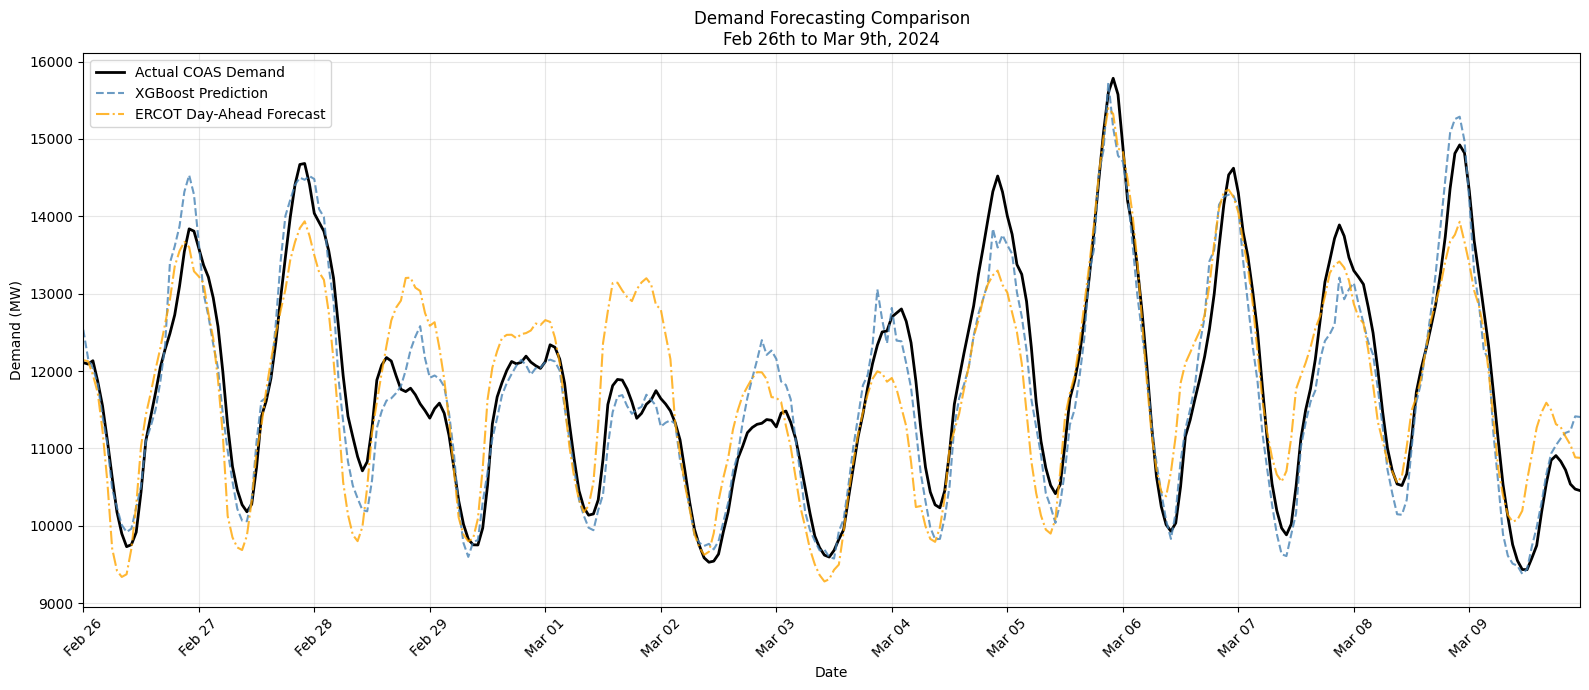

In [33]:

import matplotlib.pyplot as plt

# Compute errors
error_df = pd.DataFrame({
    "actual": y_test,
    "xgb_pred": y_pred,  # Using the predictions from best_xgb_model
}).join(ercot_forecast, how="inner")

error_df["xgb_error"]  = error_df["xgb_pred"] - error_df["actual"]
error_df["ercot_error"] = error_df["ercot_forecast"] - error_df["actual"]

error_df["abs_xgb_error"]  = error_df["xgb_error"].abs()
error_df["abs_ercot_error"] = error_df["ercot_error"].abs()

error_df["xgb_wins"] = (error_df["abs_xgb_error"] < error_df["abs_ercot_error"]).astype(int)

xgb_mae  = error_df["abs_xgb_error"].mean()
ercot_mae = error_df["abs_ercot_error"].mean()
win_rate  = error_df["xgb_wins"].mean() * 100

print(f"Hours compared:    {len(error_df)}")
print(f"XGBoost MAE:       {xgb_mae:.1f} MW")
print(f"ERCOT   MAE:       {ercot_mae:.1f} MW")
print(f"XGBoost win rate:  {win_rate:.1f}%\n")

# --- Plot the two weeks from Feb 26 to March 10 (no temperature overlay) ---

start_dt = pd.Timestamp("2024-02-26 00:00:00")
end_dt = pd.Timestamp("2024-03-10 00:00:00")    # up to but not including Mar 10
period_mask = (error_df.index >= start_dt) & (error_df.index < end_dt)
two_week_df = error_df.loc[period_mask].copy()

if len(two_week_df) == 0:
    print("No data found for the window Feb 26 - Mar 9.")
else:
    import matplotlib.dates as mdates

    fig, ax1 = plt.subplots(figsize=(16, 7))

    # Demand forecast lines (shared axis)
    ax1.plot(two_week_df.index, two_week_df["actual"], label="Actual COAS Demand", color="black", linewidth=2)
    ax1.plot(two_week_df.index, two_week_df["xgb_pred"], label="XGBoost Prediction", color="steelblue", alpha=0.8, linestyle="--")
    ax1.plot(two_week_df.index, two_week_df["ercot_forecast"], label="ERCOT Day-Ahead Forecast", color="orange", alpha=0.8, linestyle="-.")

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Demand (MW)")
    ax1.grid(True, alpha=0.3)

    ax1.legend(loc="upper left")

    # Set daily ticks for x-axis
    ax1.xaxis.set_major_locator(mdates.DayLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    # Clip the x-axis to just cover the data
    ax1.set_xlim([two_week_df.index.min(), two_week_df.index.max()])

    plt.title("Demand Forecasting Comparison\nFeb 26th to Mar 9th, 2024")
    plt.tight_layout()
    plt.show()


# 4. Analyzing feature significance and error patterns

Before diving into the distribution of errors, we extract the internal feature importance from our trained XGBoost model. This reveals which variables carry the most weight in the model's decision trees. 10 out of the 15 most important features are engineered, signifying our engineering efforts did not go to waste.

<Figure size 1000x800 with 0 Axes>

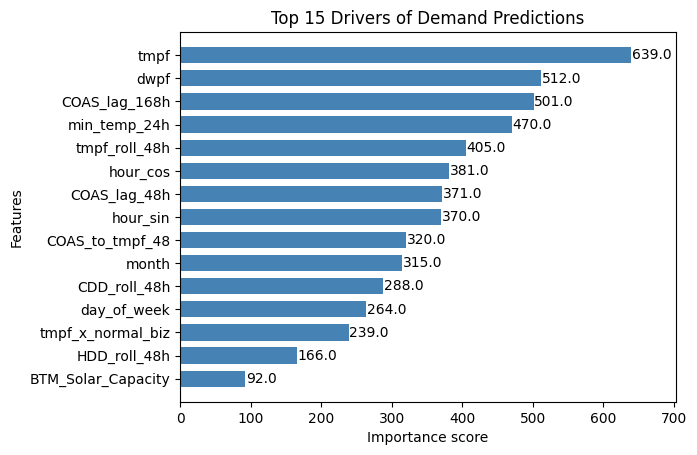

In [34]:
# Feature Importance Plot
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb_model, max_num_features=15, height=0.7, color='steelblue', grid=False)
plt.title("Top 15 Drivers of Demand Predictions")
plt.show()

Next, we examine the distribution of percentage errors. A tighter, taller bell curve centered perfectly over zero indicates a highly consistent model with low variance and minimal bias. By extracting the mean, median, and standard deviation of these errors, we can quantify systemic over-prediction or under-prediction tendencies.

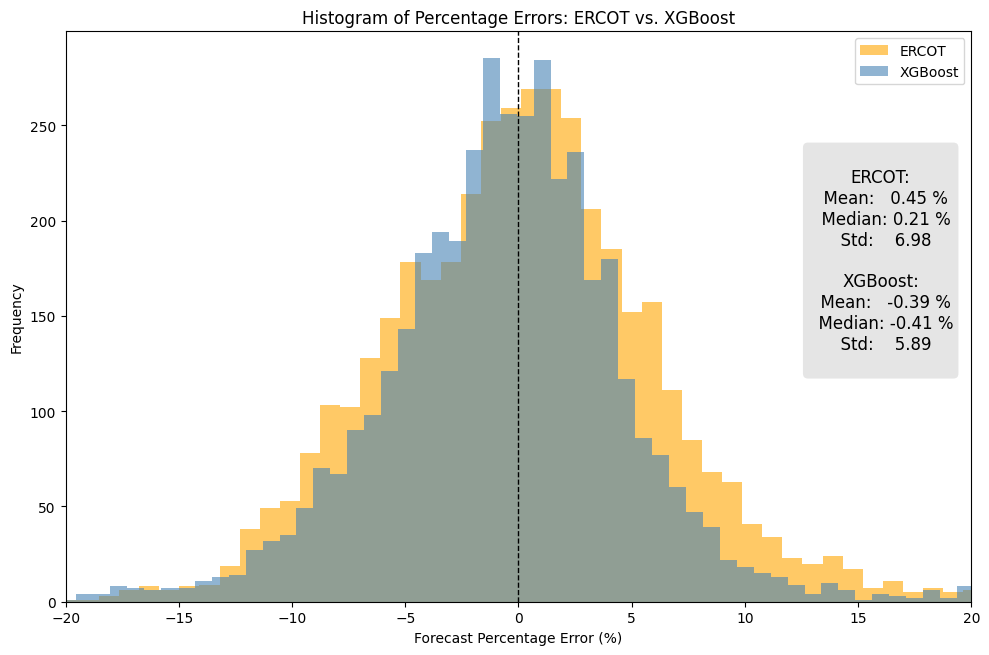

In [36]:
# Plot histograms of the percentage errors for both ERCOT and XGBoost, and include stats box per model

import numpy as np

# Calculate percentage errors
error_df['ercot_pct_error'] = (error_df['ercot_forecast'] - error_df['actual']) / error_df['actual'] * 100
error_df['xgb_pct_error'] = (error_df['xgb_pred'] - error_df['actual']) / error_df['actual'] * 100

# Compute required statistics for each model
stats = {}
for label, col in [('ERCOT', 'ercot_pct_error'), ('XGBoost', 'xgb_pct_error')]:
    arr = error_df[col].dropna()
    stats[label] = {
        'mean': arr.mean(),
        'median': arr.median(),
        'std': arr.std(),
    }

# Create a square plot
plt.figure(figsize=(10, 6.66))
plt.hist(error_df['ercot_pct_error'].dropna(), bins=80, alpha=0.6, label='ERCOT', color='orange')
plt.hist(error_df['xgb_pct_error'].dropna(), bins=80, alpha=0.6, label='XGBoost', color='steelblue')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Histogram of Percentage Errors: ERCOT vs. XGBoost")
plt.xlabel("Forecast Percentage Error (%)")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(-20, 20)

# Create stat box text
stats_text = ""
for label in ['ERCOT', 'XGBoost']:
    stats_text += "\n"
    stats_text += f"{label}:\n"
    stats_text += f"  Mean:   {stats[label]['mean']:.2f} %\n"
    stats_text += f"  Median: {stats[label]['median']:.2f} %\n"
    stats_text += f"  Std:    {stats[label]['std']:.2f}\n"

# Put the stats box in the lower right of the plot
plt.gca().text(
    0.9, 0.4,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='bottom',
    horizontalalignment='center',
    bbox=dict(boxstyle='round', facecolor='grey', alpha=0.2, edgecolor='none')
)

plt.tight_layout()

# Save as high quality
plt.savefig('error_histogram.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

Then we plot the hourly head-to-head victor between our XGBoost model and the ERCOT prediction.

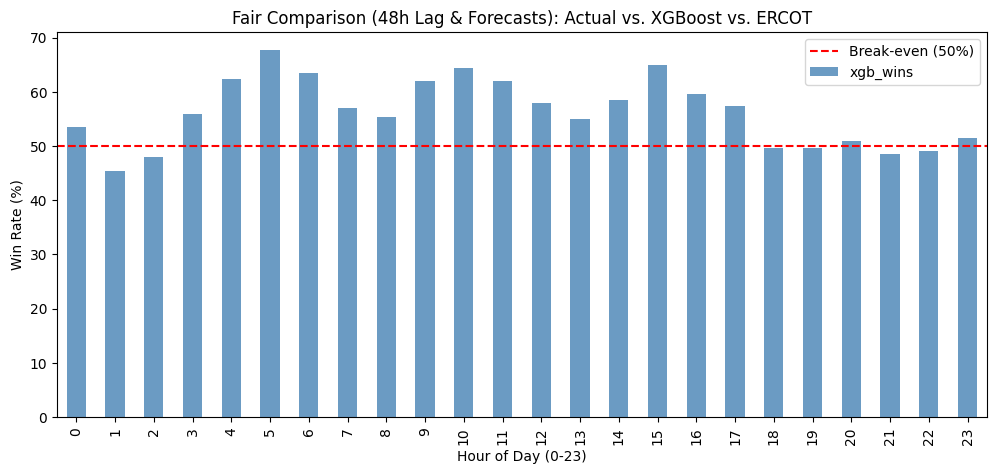

In [37]:
# Hourly Win Rate
error_df['hour'] = error_df.index.hour
hourly_win_rate = error_df.groupby('hour')['xgb_wins'].mean() * 100

plt.figure(figsize=(12, 5))
hourly_win_rate.plot(kind='bar', color='steelblue', alpha=0.8)
plt.axhline(50, color='red', linestyle='--', label='Break-even (50%)')
plt.title("Fair Comparison (48h Lag & Forecasts): Actual vs. XGBoost vs. ERCOT")
plt.ylabel("Win Rate (%)")
plt.xlabel("Hour of Day (0-23)")
plt.legend()
plt.show()

The scatter plot below serves as a reliability test for both models.

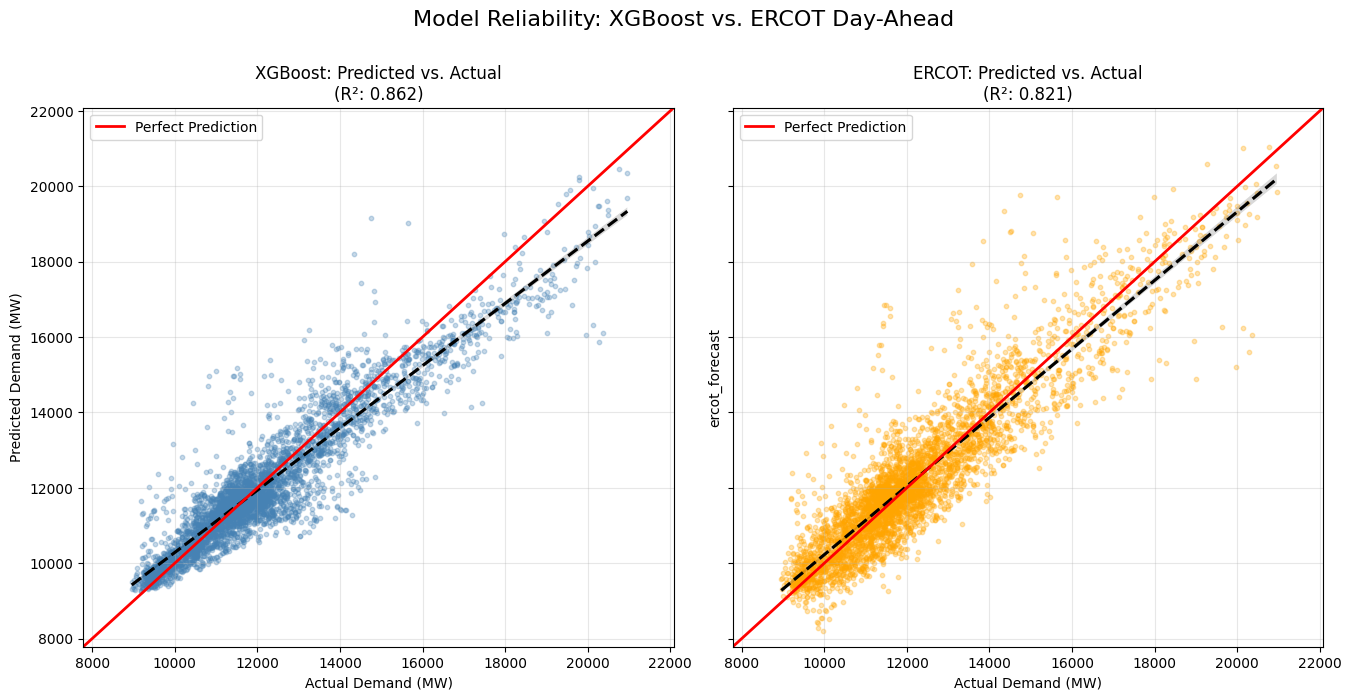

--- Peak Demand Analysis (Top 5% of Loads > 16517 MW) ---
XGBoost Peak MAE: 1288.5 MW
ERCOT Peak MAE:   921.1 MW


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 1. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.1)

# Define plot limits for a perfect square comparison
min_val = min(error_df['actual'].min(), error_df['xgb_pred'].min(), error_df['ercot_forecast'].min()) * 0.95
max_val = max(error_df['actual'].max(), error_df['xgb_pred'].max(), error_df['ercot_forecast'].max()) * 1.05

# 2. XGBoost Scatter Plot
sns.regplot(x='actual', y='xgb_pred', data=error_df, ax=ax1,
            scatter_kws={'alpha':0.3, 'color':'steelblue', 's':10},
            line_kws={'color':'black', 'linestyle':'--'})
ax1.set_title(f"XGBoost: Predicted vs. Actual\n(R²: {r2_score(error_df['actual'], error_df['xgb_pred']):.3f})")
ax1.set_xlabel("Actual Demand (MW)")
ax1.set_ylabel("Predicted Demand (MW)")

# 3. ERCOT Scatter Plot
sns.regplot(x='actual', y='ercot_forecast', data=error_df, ax=ax2,
            scatter_kws={'alpha':0.3, 'color':'orange', 's':10},
            line_kws={'color':'black', 'linestyle':'--'})
ax2.set_title(f"ERCOT: Predicted vs. Actual\n(R²: {r2_score(error_df['actual'], error_df['ercot_forecast']):.3f})")
ax2.set_xlabel("Actual Demand (MW)")

# 4. Add "Perfect Prediction" Identity Lines
for ax in [ax1, ax2]:
    ax.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, label='Perfect Prediction')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Model Reliability: XGBoost vs. ERCOT Day-Ahead", fontsize=16, y=1.02)

# Save as extremely high quality
plt.savefig('model_reliability.png', dpi=1200, bbox_inches='tight', transparent=True)
plt.show()

# 5. Print a Peak-Load Gap Analysis
peak_threshold = error_df['actual'].quantile(0.95)
xgb_peak_mae = error_df[error_df['actual'] > peak_threshold]['abs_xgb_error'].mean()
ercot_peak_mae = error_df[error_df['actual'] > peak_threshold]['abs_ercot_error'].mean()

print(f"--- Peak Demand Analysis (Top 5% of Loads > {peak_threshold:.0f} MW) ---")
print(f"XGBoost Peak MAE: {xgb_peak_mae:.1f} MW")
print(f"ERCOT Peak MAE:   {ercot_peak_mae:.1f} MW")

Grid stability is most vulnerable during unforeseen demand spikes. The following analysis isolates "critical failure" events, copmparing our model's predictions to ERCOT's predictions for days where either model under-predicted by at least 2,000 MWh in a single hour. 

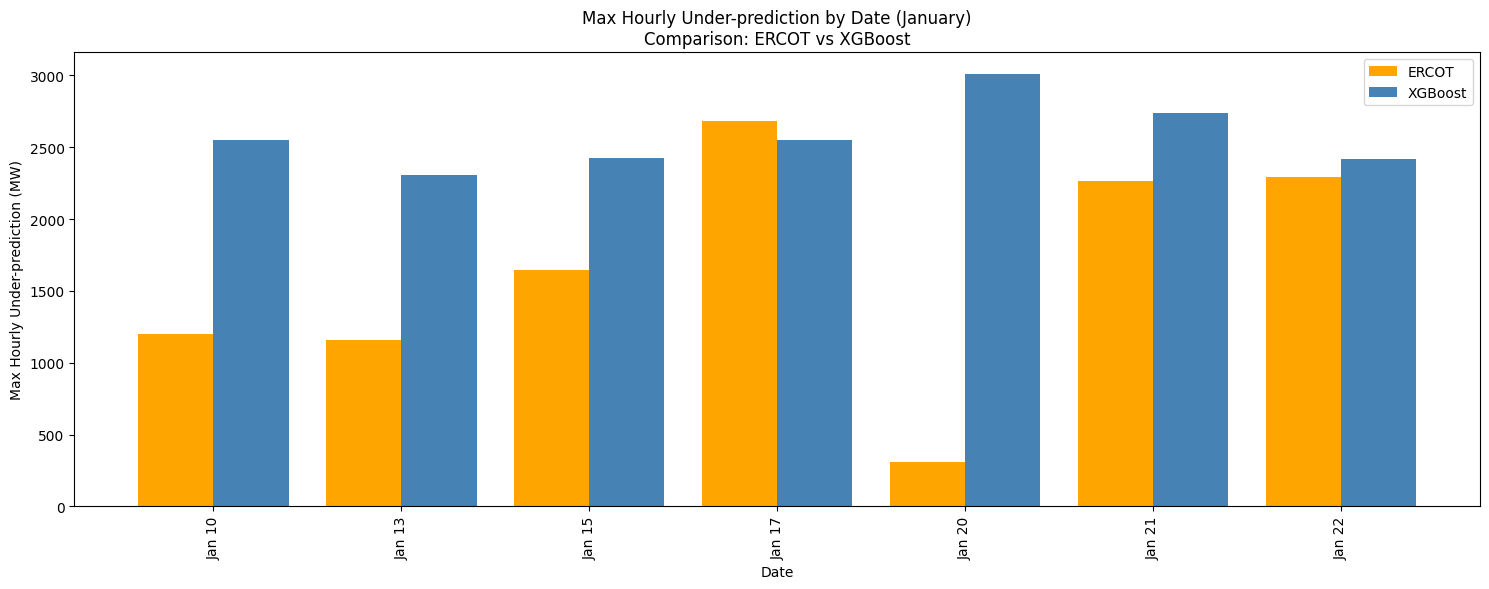

In [ ]:


critical_threshold = 13200
underprediction_threshold = 2000

base = error_df.copy()

# Robust datetime extraction, keep both date and datetime for further slicing
if 'period' in base.columns:
    dt = pd.to_datetime(base['period'], errors='coerce')
else:
    dt = pd.to_datetime(base.index, errors='coerce')

if isinstance(dt, pd.DatetimeIndex):
    date_vals = dt.date
    datetime_vals = dt
else:
    # dt is a Series
    date_vals = dt.dt.date
    datetime_vals = dt

base = base.assign(date=date_vals, datetime=datetime_vals)
base = base.dropna(subset=['date', 'datetime'])

if isinstance(base['datetime'].iloc[0], pd.Timestamp):
    jan_mask = base['datetime'].apply(lambda x: x.month == 1 if pd.notnull(x) else False)
else:
    # If already numpy.datetime64, convert for month extraction
    jan_mask = pd.to_datetime(base['datetime'], errors='coerce').dt.month == 1
base_jan = base[jan_mask].copy()

# Hourly underprediction magnitudes (only positive underprediction)
base_jan['ercot_under_mw'] = (base_jan['actual'] - base_jan['ercot_forecast']).clip(lower=0)
base_jan['xgb_under_mw'] = (base_jan['actual'] - base_jan['xgb_pred']).clip(lower=0)

# Trigger condition: high-demand hour + large miss
high_demand = base_jan['actual'] >= critical_threshold
ercot_trigger = high_demand & (base_jan['ercot_under_mw'] >= underprediction_threshold)
xgb_trigger = high_demand & (base_jan['xgb_under_mw'] >= underprediction_threshold)

dates_of_interest = sorted(
    set(base_jan.loc[ercot_trigger, 'date']) | set(base_jan.loc[xgb_trigger, 'date'])
)

# For each day, get max hourly underprediction (per model), not sum for each selected January day
if dates_of_interest:
    selected = base_jan.loc[
        base_jan['date'].isin(dates_of_interest) & high_demand,
        ['date', 'ercot_under_mw', 'xgb_under_mw']
    ].copy()

    ercot_daily_max_under = selected.groupby('date')['ercot_under_mw'].max().sort_index()
    xgb_daily_max_under = selected.groupby('date')['xgb_under_mw'].max().sort_index()
else:
    ercot_daily_max_under = pd.Series(dtype=float)
    xgb_daily_max_under = pd.Series(dtype=float)

all_dates = sorted(set(ercot_daily_max_under.index) | set(xgb_daily_max_under.index))
ercot_vals = ercot_daily_max_under.reindex(all_dates, fill_value=0).values
xgb_vals = xgb_daily_max_under.reindex(all_dates, fill_value=0).values

plt.figure(figsize=(15, 6))
width = 0.4
x = np.arange(len(all_dates))
# Format as 'Jan X'
dates_str = [f"Jan {pd.to_datetime(d).day}" for d in all_dates]

plt.bar(x - width / 2, ercot_vals, width=width, color='orange',
        label='ERCOT')
plt.bar(x + width / 2, xgb_vals, width=width, color='steelblue',
        label='XGBoost')

plt.xlabel("Date")
plt.ylabel("Max Hourly Under-prediction (MW)")
plt.title(
    f"Max Hourly Under-prediction by Date (January)\nComparison: ERCOT vs XGBoost"
)
plt.xticks(x, dates_str, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()